# Motor Imagery Decoder — Train OFFLINE, Evaluate ONLINE (FES vs NOFES)

For each subject × offline-session, train a CSP + LDA classifier on the OFFLINE recording, then apply it to the two matched ONLINE sessions.

**Pair 1:** train on `S001 OFFLINE_FES` → test on `S002 ONLINE_FES` and `S003 ONLINE_NOFES`
**Pair 2:** train on `S004 OFFLINE_NOFES` → test on `S006 ONLINE_FES` and `S005 ONLINE_NOFES`

**Metrics reported per (subject × pair × condition):**
1. **Classification accuracy** — fraction of cued trials correctly classified
2. **Classification amplitude** — mean |LDA decision-function value|
3. **SNR** — (a) Fisher ratio of the LDA projection on online data, and (b) mu-band power ratio REST / MI over motor channels C3/Cz/C4

In [1]:
# Install dependencies if needed
# !pip install pyxdf mne scipy numpy matplotlib

In [2]:
import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pyxdf
from scipy.signal import welch, butter, filtfilt, iirnotch
from scipy.linalg import eigh

plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

## Configuration

In [3]:
DATA_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'Group 2 - Glove')

# Marker codes (from experiment trigger table)
MI_BEGIN       = 200
MI_END         = 220
MI_EARLYSTOP   = 240   # online only: live classifier fired → successful MI detection
REST_BEGIN     = 100
REST_END       = 120
REST_EARLYSTOP = 140   # online only: live classifier fired → successful REST detection
ROBOT_BEGIN    = 300
ROBOT_END      = 320

TARGET_MARKERS = [100, 120, 140, 200, 220, 240]

T_PRE  = -1.0
T_POST =  5.0

# ── Preprocessing ────────────────────────────────────────────────────────────
NOTCH_FREQ     = 60.0
NOTCH_Q        = 30
BP_LO, BP_HI   = 8.0, 30.0
USE_CAR        = True
PTP_REJECT_UV  = 100.0

N_CSP = 4

NON_EEG = {'AUX1', 'AUX2', 'AUX3', 'AUX7', 'AUX8', 'AUX9', 'TRIGGER'}
RENAME  = {'FP1':'Fp1','FPZ':'Fpz','FP2':'Fp2','FZ':'Fz','CZ':'Cz',
           'PZ':'Pz','POZ':'POz','OZ':'Oz'}

MOTOR_CH = ['C3', 'Cz', 'C4']
MU_BAND  = (8, 13)

# Sessions are stored with compound key "{ses_id}_{kind}_{stim}" and looked up
# positionally: idx=0 is the first session of that (kind, stim) type sorted by
# key, idx=1 is the second. This handles subjects like 002 where OFFLINE and
# ONLINE sessions share the same ses-Sxxx number in the filename.
PAIRS = [
    {'name':  'Pair1 (train=OFFLINE_FES)',
     'train':        {'kind': 'OFFLINE', 'stim': 'FES',   'idx': 0},
     'online_fes':   {'kind': 'ONLINE',  'stim': 'FES',   'idx': 0},
     'online_nofes': {'kind': 'ONLINE',  'stim': 'NOFES', 'idx': 0},
    },
    {'name':  'Pair2 (train=OFFLINE_NOFES)',
     'train':        {'kind': 'OFFLINE', 'stim': 'NOFES', 'idx': 0},
     'online_fes':   {'kind': 'ONLINE',  'stim': 'FES',   'idx': 1},
     'online_nofes': {'kind': 'ONLINE',  'stim': 'NOFES', 'idx': 1},
    },
]

## Helper Functions

In [4]:
# ── XDF loading + session parsing ─────────────────────────────────────────────

def get_channel_names_from_xdf(eeg_stream):
    ch_desc  = eeg_stream['info']['desc'][0]
    channels = ch_desc.get('channels', [{}])[0].get('channel', [])
    return [ch['label'][0] for ch in channels]


_SESSION_RE = re.compile(r'ses-(S\d+)(O[A-Z]*LINE)_(FES|NOFES)')
_SUBJ_RE    = re.compile(r'SUBJ_(\d+)')

def parse_session(path):
    base   = os.path.basename(path)
    m_subj = _SUBJ_RE.search(base)
    m_ses  = _SESSION_RE.search(base)
    if not (m_subj and m_ses):
        return None
    ses_id, raw_kind, stim = m_ses.group(1), m_ses.group(2), m_ses.group(3)
    kind = 'OFFLINE' if 'OFF' in raw_kind else 'ONLINE'
    return m_subj.group(1), ses_id, kind, stim


def load_xdf_file(filepath):
    streams, _ = pyxdf.load_xdf(filepath)

    eeg_stream = marker_stream = None
    for s in streams:
        stype = s['info']['type'][0].lower()
        if stype == 'eeg':       eeg_stream    = s
        elif stype == 'markers': marker_stream = s
    if eeg_stream is None or marker_stream is None:
        eeg_stream    = streams[0]
        marker_stream = streams[1] if len(streams) > 1 else None

    eeg_timestamps = np.array(eeg_stream['time_stamps'])
    eeg_data       = np.array(eeg_stream['time_series']).T
    channel_names  = get_channel_names_from_xdf(eeg_stream)
    sfreq          = float(eeg_stream['info']['nominal_srate'][0])

    valid_idx     = [i for i, ch in enumerate(channel_names) if ch not in NON_EEG]
    channel_names = [channel_names[i] for i in valid_idx]
    eeg_data      = eeg_data[valid_idx, :]
    channel_names = [RENAME.get(ch, ch) for ch in channel_names]

    ts_arr      = np.asarray(marker_stream['time_series'], dtype=float)
    marker_data = ts_arr[:, 0].astype(int)
    marker_ts   = ts_arr[:, 1]
    keep        = np.isin(marker_data, TARGET_MARKERS)
    return eeg_data, eeg_timestamps, marker_data[keep], marker_ts[keep], channel_names, sfreq


# ── Preprocessing primitives ─────────────────────────────────────────────────

def notch_filter(data, freq, sfreq, Q=NOTCH_Q):
    b, a = iirnotch(freq, Q, fs=sfreq)
    return filtfilt(b, a, data, axis=-1)


def car(data):
    return data - data.mean(axis=0, keepdims=True)


def bandpass(data, lo, hi, sfreq, order=4):
    nyq  = sfreq / 2.0
    b, a = butter(order, [max(lo, 0.5) / nyq, min(hi, nyq - 0.1) / nyq], btype='band')
    return filtfilt(b, a, data, axis=-1)


def reject_by_ptp(X, thresh_uv=PTP_REJECT_UV):
    if X.size == 0:
        return np.zeros(0, dtype=bool)
    ptp = X.max(axis=-1) - X.min(axis=-1)
    return ptp.max(axis=-1) < thresh_uv


def extract_epochs(eeg_data, eeg_ts, marker_data, marker_ts, sfreq, begin_code,
                   t_pre=T_PRE, t_post=T_POST):
    epochs = []
    n_pre  = int(abs(t_pre) * sfreq)
    for bi in np.where(marker_data == begin_code)[0]:
        t_start = marker_ts[bi]
        i0 = np.searchsorted(eeg_ts, t_start + t_pre)
        i1 = np.searchsorted(eeg_ts, t_start + t_post)
        if i0 < 0 or i1 > eeg_data.shape[1]:
            continue
        ep = eeg_data[:, i0:i1].copy()
        if ep.shape[1] > n_pre:
            ep -= ep[:, :n_pre].mean(axis=1, keepdims=True)
        epochs.append(ep)
    if not epochs:
        return np.empty((0, eeg_data.shape[0], 0))
    min_len = min(e.shape[-1] for e in epochs)
    return np.stack([e[:, :min_len] for e in epochs])


def marker_accuracy(marker_data):
    """Online accuracy from EARLYSTOP markers: (MI_EARLYSTOP + REST_EARLYSTOP) / total trials.
    Returns None for offline sessions (no EARLYSTOP markers present).
    """
    n_mi_trials   = int((marker_data == MI_BEGIN).sum())
    n_rest_trials = int((marker_data == REST_BEGIN).sum())
    n_total = n_mi_trials + n_rest_trials
    if n_total == 0:
        return None
    n_mi_correct   = int((marker_data == MI_EARLYSTOP).sum())
    n_rest_correct = int((marker_data == REST_EARLYSTOP).sum())
    # If no EARLYSTOP markers present at all, this is an offline session
    if n_mi_correct + n_rest_correct == 0:
        return None
    return (n_mi_correct + n_rest_correct) / n_total


def load_session_epochs(filepath):
    """Preprocessing pipeline: notch → CAR → bandpass → epoch → PTP-reject.
    Returns X, y, ch_names, sfreq, n_rejected, mk_acc
    where mk_acc = marker-based online accuracy (None for offline sessions).
    """
    eeg, eeg_ts, mk, mk_ts, ch_names, sfreq = load_xdf_file(filepath)

    # Marker-based accuracy before any EEG processing (counts all trials as seen by the live system)
    mk_acc = marker_accuracy(mk)

    eeg = notch_filter(eeg, NOTCH_FREQ, sfreq)
    if USE_CAR:
        eeg = car(eeg)
    eeg_bp = bandpass(eeg, BP_LO, BP_HI, sfreq)

    mi   = extract_epochs(eeg_bp, eeg_ts, mk, mk_ts, sfreq, MI_BEGIN)
    rest = extract_epochs(eeg_bp, eeg_ts, mk, mk_ts, sfreq, REST_BEGIN)

    n_pre = int(abs(T_PRE) * sfreq)
    if mi.shape[-1]   > n_pre: mi   = mi[..., n_pre:]
    if rest.shape[-1] > n_pre: rest = rest[..., n_pre:]

    n = min(mi.shape[-1], rest.shape[-1]) if (mi.size and rest.size) else 0
    mi, rest = mi[..., :n], rest[..., :n]

    n0_mi, n0_rest = len(mi), len(rest)
    mi   = mi[reject_by_ptp(mi)]
    rest = rest[reject_by_ptp(rest)]
    n_rejected = (n0_mi - len(mi)) + (n0_rest - len(rest))

    X = np.concatenate([mi, rest], axis=0) if (len(mi) or len(rest)) else np.empty((0, len(ch_names), 0))
    y = np.concatenate([np.ones(len(mi), int), np.zeros(len(rest), int)])
    return X, y, ch_names, sfreq, n_rejected, mk_acc


# ── CSP + LDA (2-class, numpy/scipy only) ────────────────────────────────────

def _mean_cov(X):
    covs = np.einsum('ijk,ilk->ijl', X, X)
    covs /= np.trace(covs, axis1=1, axis2=2)[:, None, None]
    return covs.mean(axis=0)


class CSPLDA:
    """CSP log-var features + LDA. Ramoser 2000; Blankertz 2008.
    Ledoit-Wolf shrinkage keeps the generalized eigenproblem well-posed after CAR.
    """

    def __init__(self, n_csp=N_CSP, cov_shrink=0.05, lda_reg=1e-4):
        self.n_csp      = n_csp
        self.cov_shrink = cov_shrink
        self.lda_reg    = lda_reg

    def fit(self, X, y):
        assert set(np.unique(y)) == {0, 1}
        C1 = _mean_cov(X[y == 1])
        C0 = _mean_cov(X[y == 0])
        n_ch = C1.shape[0]
        s = self.cov_shrink
        C1 = (1 - s) * C1 + s * (np.trace(C1) / n_ch) * np.eye(n_ch)
        C0 = (1 - s) * C0 + s * (np.trace(C0) / n_ch) * np.eye(n_ch)
        evals, evecs = eigh(C1, C0 + C1)
        order  = np.argsort(evals)
        k      = self.n_csp // 2
        self.filters_ = np.concatenate([evecs[:, order[:k]],
                                        evecs[:, order[-k:]]], axis=1).T
        F = self._features(X)
        mu1, mu0 = F[y == 1].mean(0), F[y == 0].mean(0)
        Sw = np.cov(F[y == 1].T, ddof=1) + np.cov(F[y == 0].T, ddof=1)
        Sw += self.lda_reg * np.eye(Sw.shape[0])
        self.coef_      = np.linalg.solve(Sw, mu1 - mu0)
        self.intercept_ = -self.coef_ @ ((mu1 + mu0) / 2)
        return self

    def _features(self, X):
        Z   = np.einsum('fc,ncs->nfs', self.filters_, X)
        var = Z.var(axis=-1, ddof=1)
        return np.log(var / var.sum(axis=1, keepdims=True))

    def decision_function(self, X):
        return self._features(X) @ self.coef_ + self.intercept_

    def predict(self, X):
        return (self.decision_function(X) > 0).astype(int)


# ── Evaluation metrics ───────────────────────────────────────────────────────

def evaluate(clf, X, y):
    margin = clf.decision_function(X)
    pred   = (margin > 0).astype(int)
    amp    = np.abs(margin).mean()
    m1, m0 = margin[y == 1], margin[y == 0]
    fisher = (m1.mean() - m0.mean()) ** 2 / (m1.var(ddof=1) + m0.var(ddof=1) + 1e-30)
    return dict(amp=amp, fisher=fisher, margin=margin, y=y, pred=pred)


def spectral_snr(X, y, ch_idx, sfreq, band=MU_BAND):
    def band_pwr(sig):
        f, p = welch(sig, fs=sfreq,
                     nperseg=min(int(sfreq * 2), sig.shape[-1]),
                     noverlap=int(sfreq), axis=-1)
        m = (f >= band[0]) & (f < band[1])
        return np.trapezoid(p[..., m], f[m], axis=-1).mean()
    return band_pwr(X[y == 0][:, ch_idx, :]) / (band_pwr(X[y == 1][:, ch_idx, :]) + 1e-30)

## Load Data

In [5]:
xdf_files = sorted(glob.glob(os.path.join(DATA_DIR, '*.xdf')))
print(f'Found {len(xdf_files)} XDF file(s).')
print(f'Preprocessing: notch {NOTCH_FREQ:.0f} Hz → '
      f'{"CAR → " if USE_CAR else ""}bandpass {BP_LO:.0f}–{BP_HI:.0f} Hz → '
      f'baseline-correct → PTP-reject @ {PTP_REJECT_UV:.0f} µV\n')

sessions  = {}
total_rej = 0

for fp in xdf_files:
    meta = parse_session(fp)
    if meta is None:
        print(f'  SKIP (unparsed): {os.path.basename(fp)}')
        continue
    subj, ses_id, kind, stim = meta
    try:
        X, y, ch_names, sfreq, n_rej, mk_acc = load_session_epochs(fp)
    except Exception as e:
        print(f'  ERROR {os.path.basename(fp)}: {e}')
        continue

    # Compound key prevents collision when multiple session types share the same ses_id
    key = f'{ses_id}_{kind}_{stim}'
    sessions.setdefault(subj, {})[key] = dict(
        X=X, y=y, kind=kind, stim=stim,
        ch_names=ch_names, sfreq=sfreq,
        mk_acc=mk_acc, file=os.path.basename(fp))
    total_rej += n_rej

    acc_str = f'  mk_acc={mk_acc:.3f}' if mk_acc is not None else ''
    print(f'  {subj}/{ses_id}  {kind:<7} {stim:<5}  '
          f'n={len(y):3d}  (MI={int(y.sum())}, REST={int((1-y).sum())})  '
          f'rej={n_rej}{acc_str}')

subjects = sorted(sessions.keys())
print(f'\nLoaded {len(subjects)} subject(s): {subjects}  |  '
      f'total artifact-rejected epochs: {total_rej}')


def pick_session(subj_ses, kind, stim, idx):
    """Return the idx-th session matching (kind, stim), sorted by key. None if not enough."""
    matches = sorted(
        (v for v in subj_ses.values() if v['kind'] == kind and v['stim'] == stim),
        key=lambda v: v['file']   # alphabetical file order = recording order
    )
    return matches[idx] if idx < len(matches) else None

Found 24 XDF file(s).
Preprocessing: notch 60 Hz → CAR → bandpass 8–30 Hz → baseline-correct → PTP-reject @ 100 µV



  002/S001  OFFLINE FES    n= 85  (MI=43, REST=42)  rej=5


  002/S002  ONLINE  FES    n= 53  (MI=27, REST=26)  rej=7  mk_acc=0.883


  002/S003  ONLINE  NOFES  n= 52  (MI=26, REST=26)  rej=8  mk_acc=0.833


  002/S004  OFFLINE NOFES  n= 90  (MI=45, REST=45)  rej=0


...

  009/S002  ONLINE  FES    n= 42  (MI=21, REST=21)  rej=18  mk_acc=0.717


  009/S003  ONLINE  NOFES  n=  1  (MI=1, REST=0)  rej=59  mk_acc=0.717


  009/S004  OFFLINE NOFES  n= 86  (MI=42, REST=44)  rej=4


  009/S005  ONLINE  NOFES  n= 60  (MI=30, REST=30)  rej=0  mk_acc=0.850


  009/S006  ONLINE  FES    n= 50  (MI=26, REST=24)  rej=10  mk_acc=0.817

Loaded 4 subject(s): ['002', '003', '005', '009']  |  total artifact-rejected epochs: 184


## Verify Session Layout

In [6]:
# Verify channel layout is consistent across sessions, locate motor channels
ref_subj = subjects[0]
ref_ses  = next(iter(sessions[ref_subj].values()))
channel_names_global = ref_ses['ch_names']
sfreq_global         = ref_ses['sfreq']

mismatches = [f'{subj}/{sid}' for subj in subjects for sid, s in sessions[subj].items()
              if s['ch_names'] != channel_names_global]
if mismatches:
    print('!! channel mismatch in:', mismatches)

motor_idx_global = [channel_names_global.index(c) for c in MOTOR_CH
                    if c in channel_names_global]

print(f'Channels ({len(channel_names_global)}): {channel_names_global}')
print(f'Sampling rate: {sfreq_global} Hz')
print(f'Motor channels {MOTOR_CH} → indices {motor_idx_global}')

Channels (32): ['Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6', 'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6', 'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2']
Sampling rate: 512.0 Hz
Motor channels ['C3', 'Cz', 'C4'] → indices [14, 15, 16]


## Train CSP + LDA on OFFLINE, Evaluate on ONLINE

In [7]:
MIN_TEST_TRIALS = 10

results = []

for subj in subjects:
    subj_ses = sessions[subj]

    for pair in PAIRS:
        train = pick_session(subj_ses, pair['train']['kind'],  pair['train']['stim'],  pair['train']['idx'])
        te_f  = pick_session(subj_ses, pair['online_fes']['kind'],   pair['online_fes']['stim'],   pair['online_fes']['idx'])
        te_n  = pick_session(subj_ses, pair['online_nofes']['kind'], pair['online_nofes']['stim'], pair['online_nofes']['idx'])

        missing = [role for role, ses in [('train', train), ('online_fes', te_f), ('online_nofes', te_n)] if ses is None]
        if missing:
            print(f'[{subj}] {pair["name"]}: no session found for {missing} — skipping')
            continue

        if set(np.unique(train['y'])) != {0, 1}:
            print(f'[{subj}] {pair["name"]}: training set lacks both classes — skipping')
            continue

        clf       = CSPLDA(n_csp=N_CSP).fit(train['X'], train['y'])
        train_acc = (clf.predict(train['X']) == train['y']).mean()

        for te, cond_label in [(te_f, 'FES'), (te_n, 'NOFES')]:
            acc = te['mk_acc']
            if acc is None:
                print(f'[{subj}] {pair["name"]} / {cond_label}: no EARLYSTOP markers — skipping')
                continue

            if len(te['y']) < MIN_TEST_TRIALS or set(np.unique(te['y'])) != {0, 1}:
                print(f'[{subj}] {pair["name"]} / {cond_label}: only {len(te["y"])} clean epochs — '
                      f'acc={acc:.3f} (marker-based), skipping EEG metrics')
                continue

            res   = evaluate(clf, te['X'], te['y'])
            snr_s = spectral_snr(te['X'], te['y'], motor_idx_global, te['sfreq'])

            results.append(dict(
                subject=subj, pair=pair['name'], condition=cond_label,
                train_file=train['file'], test_file=te['file'],
                train_acc=train_acc, n_test=len(te['y']),
                acc=acc,
                amp=res['amp'], fisher=res['fisher'], mu_snr=snr_s,
                margin=res['margin'], y_test=res['y'], pred=res['pred'],
            ))

hdr = (f'{"Subj":<5} {"Pair":<28} {"Cond":<6} {"n":>4} '
       f'{"trainAcc":>9} {"mkAcc":>7} {"|marg|":>8} {"Fisher":>8} {"muSNR":>8}')
print('\n' + hdr)
print('-' * len(hdr))
for r in results:
    print(f'{r["subject"]:<5} {r["pair"]:<28} {r["condition"]:<6} {r["n_test"]:>4} '
          f'{r["train_acc"]:>9.3f} {r["acc"]:>7.3f} {r["amp"]:>8.3f} '
          f'{r["fisher"]:>8.3f} {r["mu_snr"]:>8.3f}')

[009] Pair1 (train=OFFLINE_FES) / NOFES: only 1 clean epochs — acc=0.717 (marker-based), skipping EEG metrics

Subj  Pair                         Cond      n  trainAcc   mkAcc   |marg|   Fisher    muSNR
-------------------------------------------------------------------------------------------
002   Pair1 (train=OFFLINE_FES)    FES      53     0.659   0.883    0.778    0.288    1.197
002   Pair1 (train=OFFLINE_FES)    NOFES    52     0.659   0.833    1.162    0.073    1.452
002   Pair2 (train=OFFLINE_NOFES)  FES      56     0.811   0.917    1.012    3.133    1.665
002   Pair2 (train=OFFLINE_NOFES)  NOFES    60     0.811   0.850    0.756    0.695    1.576
003   Pair1 (train=OFFLINE_FES)    FES      59     0.843   0.750    0.879    0.017    1.347
003   Pair1 (train=OFFLINE_FES)    NOFES    38     0.843   0.763    0.910    0.683    1.219
003   Pair2 (train=OFFLINE_NOFES)  FES      52     0.907   0.767    1.166    0.000    1.273
003   Pair2 (train=OFFLINE_NOFES)  NOFES    43     0.907   0.

---
## Figure 1 — Per-metric comparison (FES vs NOFES)

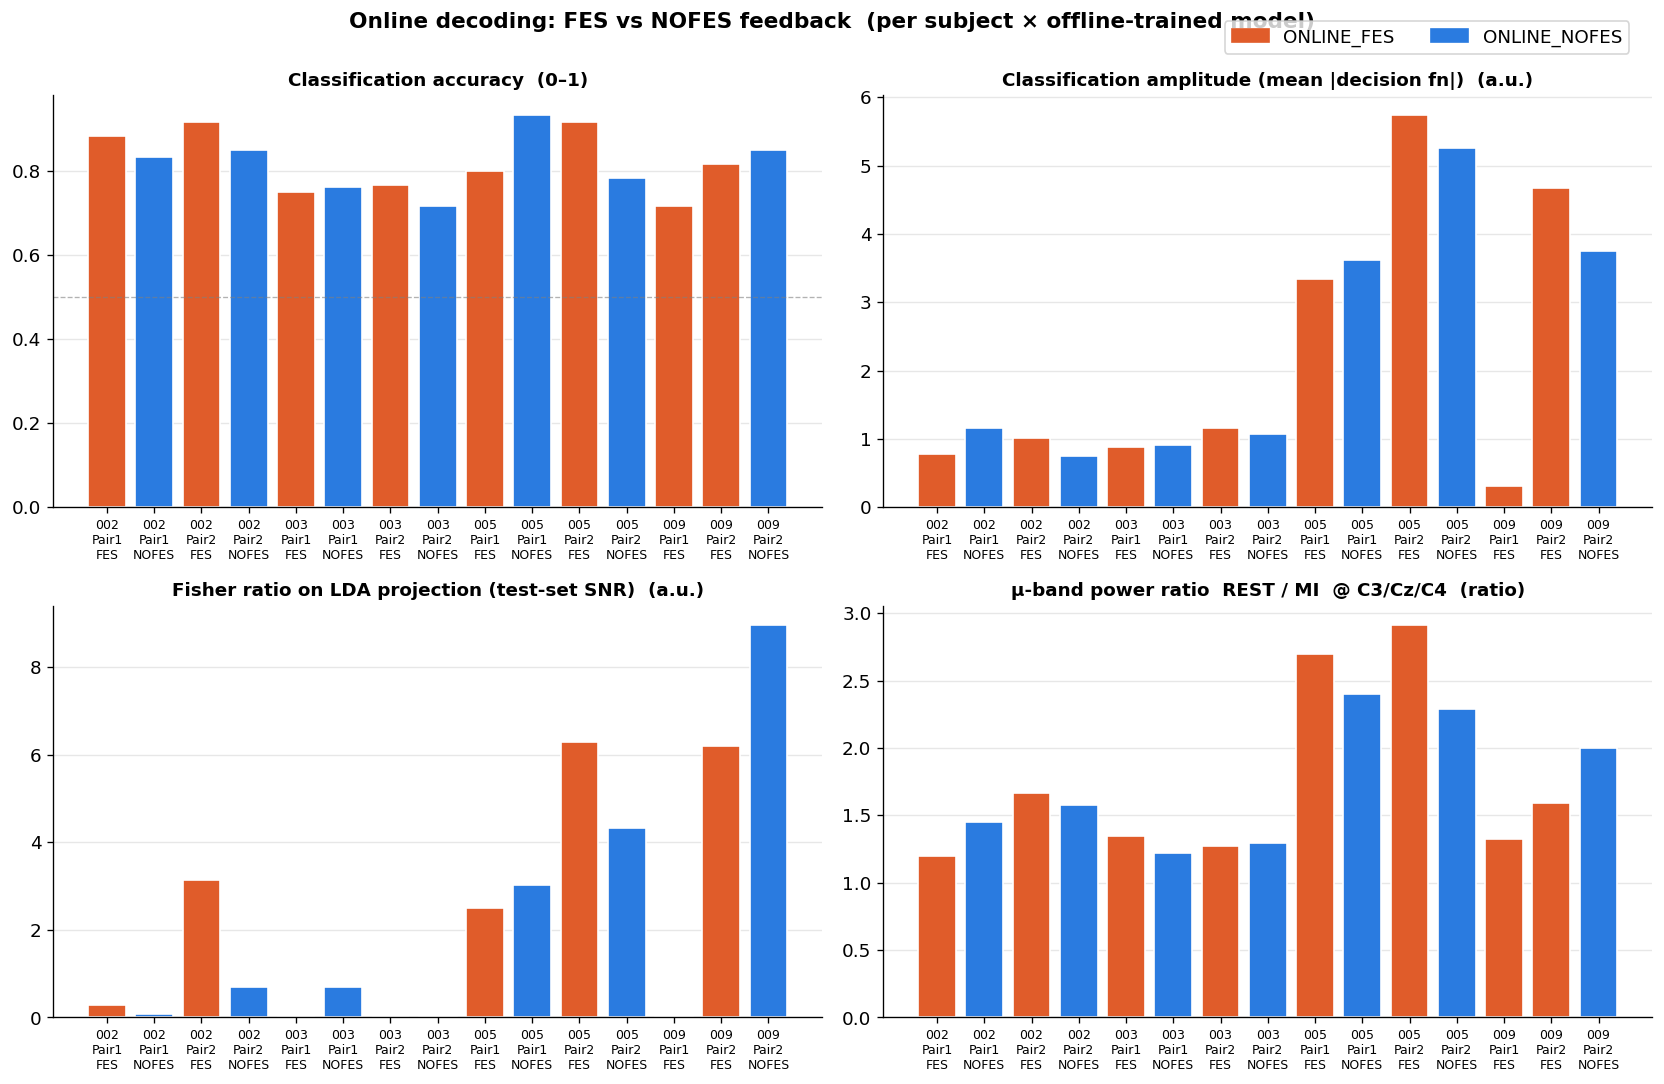

Saved: fes_vs_nofes_metrics.png


In [8]:
METRICS = [
    ('acc',    'Classification accuracy',                            '0–1'),
    ('amp',    'Classification amplitude (mean |decision fn|)',      'a.u.'),
    ('fisher', 'Fisher ratio on LDA projection (test-set SNR)',      'a.u.'),
    ('mu_snr', 'μ-band power ratio  REST / MI  @ C3/Cz/C4',          'ratio'),
]

cond_color = {'FES': '#E05C2A', 'NOFES': '#2A7BE0'}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Online decoding: FES vs NOFES feedback  (per subject × offline-trained model)',
             fontsize=13, fontweight='bold', y=1.00)

for ax, (key, title, unit) in zip(axes.ravel(), METRICS):
    labels, vals, colors = [], [], []
    for subj in subjects:
        for pair in PAIRS:
            tag = pair['name'].split()[0]   # "Pair1" / "Pair2"
            for cond in ('FES', 'NOFES'):
                row = next((r for r in results
                            if r['subject']==subj and r['pair']==pair['name']
                            and r['condition']==cond), None)
                if row is None: continue
                labels.append(f'{subj}\n{tag}\n{cond}')
                vals.append(row[key])
                colors.append(cond_color[cond])
    x = np.arange(len(vals))
    ax.bar(x, vals, color=colors, edgecolor='white', zorder=2)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=7.5)
    ax.set_title(f'{title}  ({unit})', fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
    if key == 'acc':
        ax.axhline(0.5, color='gray', linestyle='--', lw=0.8, alpha=0.6)

fig.legend(handles=[Patch(color=cond_color['FES'],   label='ONLINE_FES'),
                    Patch(color=cond_color['NOFES'], label='ONLINE_NOFES')],
           loc='upper right', ncol=2, bbox_to_anchor=(0.98, 1.0))
plt.tight_layout()
plt.savefig('fes_vs_nofes_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fes_vs_nofes_metrics.png')

---
## Figure 2 — LDA decision-function distributions

Visualizes classification amplitude and separability directly: wider FES vs NOFES spread between MI and REST curves = higher Fisher ratio and larger mean |margin|.

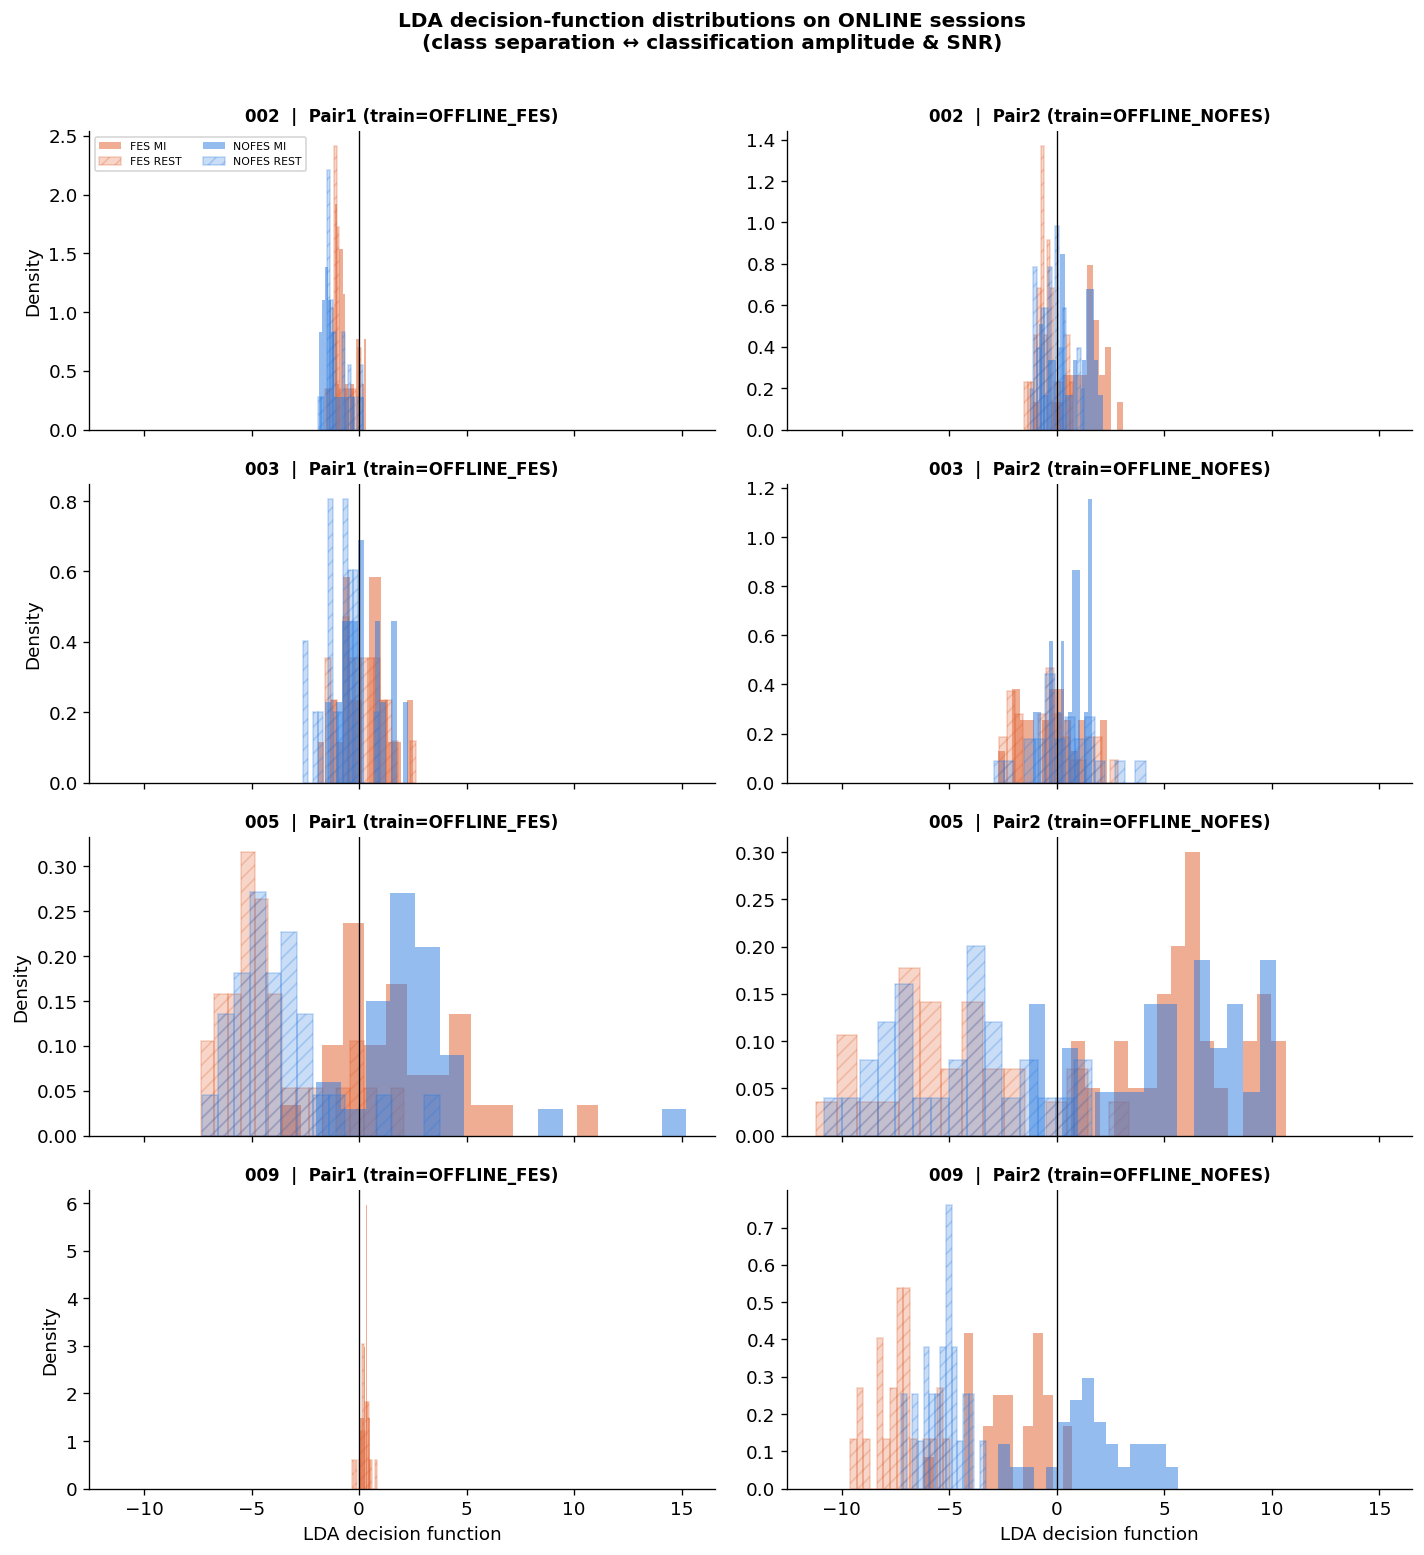

Saved: decision_margin_distributions.png


In [9]:
fig, axes = plt.subplots(len(subjects), len(PAIRS),
                         figsize=(6 * len(PAIRS), 3.2 * len(subjects)),
                         sharex=True, squeeze=False)
fig.suptitle('LDA decision-function distributions on ONLINE sessions\n'
             '(class separation ↔ classification amplitude & SNR)',
             fontsize=12, fontweight='bold', y=1.01)

for i, subj in enumerate(subjects):
    for j, pair in enumerate(PAIRS):
        ax = axes[i][j]
        for cond, color in cond_color.items():
            row = next((r for r in results
                        if r['subject']==subj and r['pair']==pair['name']
                        and r['condition']==cond), None)
            if row is None: continue
            m_mi   = row['margin'][row['y_test'] == 1]
            m_rest = row['margin'][row['y_test'] == 0]
            ax.hist(m_mi,   bins=15, alpha=0.5,  color=color,
                    label=f'{cond} MI',   density=True)
            ax.hist(m_rest, bins=15, alpha=0.25, color=color, hatch='///',
                    edgecolor=color, label=f'{cond} REST', density=True)
        ax.axvline(0, color='k', lw=0.8)
        ax.set_title(f'{subj}  |  {pair["name"]}', fontsize=10, fontweight='bold')
        if j == 0:                     ax.set_ylabel('Density')
        if i == len(subjects) - 1:     ax.set_xlabel('LDA decision function')
        ax.spines[['top','right']].set_visible(False)
        if i == 0 and j == 0:
            ax.legend(fontsize=6.5, loc='upper left', ncol=2)

plt.tight_layout()
plt.savefig('decision_margin_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: decision_margin_distributions.png')

---
## Figure 3 — Paired Δ (FES − NOFES) per metric

Within each (subject × pair), FES and NOFES sessions use the same offline-trained model. Positive bars mean FES > NOFES; negative means NOFES > FES. This removes the offline-model-quality confound and isolates the effect of feedback type.

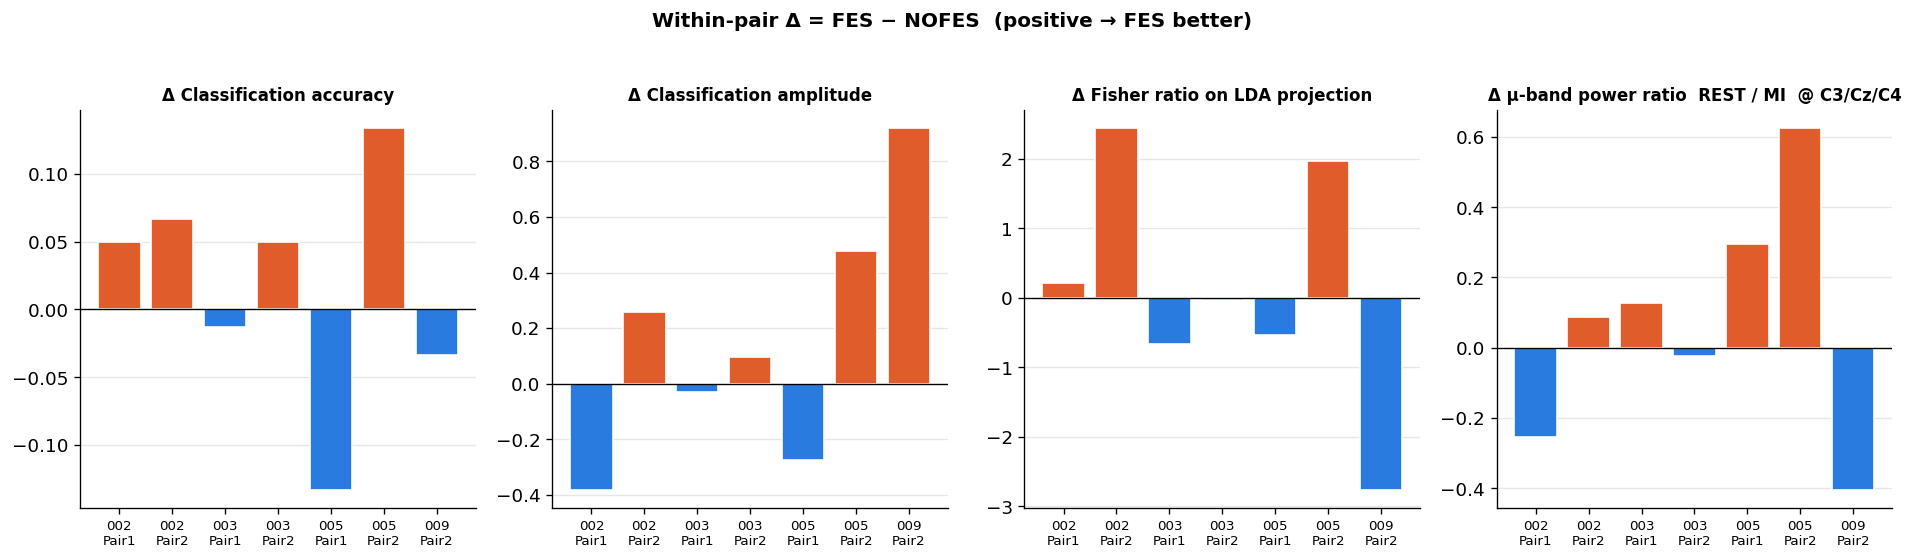

Saved: fes_minus_nofes_delta.png


In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
fig.suptitle('Within-pair Δ = FES − NOFES  (positive → FES better)',
             fontsize=12, fontweight='bold', y=1.03)

for ax, (key, title, _) in zip(axes, METRICS):
    labels, deltas = [], []
    for subj in subjects:
        for pair in PAIRS:
            fes = next((r for r in results if r['subject']==subj and r['pair']==pair['name']
                        and r['condition']=='FES'),   None)
            nof = next((r for r in results if r['subject']==subj and r['pair']==pair['name']
                        and r['condition']=='NOFES'), None)
            if fes is None or nof is None: continue
            deltas.append(fes[key] - nof[key])
            labels.append(f'{subj}\n{pair["name"].split()[0]}')

    colors = ['#E05C2A' if d > 0 else '#2A7BE0' for d in deltas]
    ax.bar(np.arange(len(deltas)), deltas, color=colors, edgecolor='white', zorder=2)
    ax.axhline(0, color='k', lw=0.8)
    ax.set_xticks(np.arange(len(deltas)))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(f'Δ {title.split("(")[0].strip()}', fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('fes_minus_nofes_delta.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fes_minus_nofes_delta.png')

---
## Summary Statistics

In [11]:
# Build only pairs where BOTH FES and NOFES survived evaluation
paired = []
for subj in subjects:
    for pair in PAIRS:
        fes = next((r for r in results if r['subject']==subj and r['pair']==pair['name']
                    and r['condition']=='FES'),   None)
        nof = next((r for r in results if r['subject']==subj and r['pair']==pair['name']
                    and r['condition']=='NOFES'), None)
        if fes and nof:
            paired.append((fes, nof))

print(f'=== Aggregate across {len(paired)} complete (subject × pair) comparisons ===\n')

hdr = f'{"Metric":<28} {"FES (mean ± sd)":>22} {"NOFES (mean ± sd)":>22} {"paired Δ":>12}'
print(hdr); print('-' * len(hdr))
for k, label in [('acc',    'Classification accuracy'),
                 ('amp',    'Classification amplitude'),
                 ('fisher', 'Fisher ratio (test SNR)'),
                 ('mu_snr', 'μ-band SNR  (REST/MI)')]:
    fes_v = np.array([f[k] for f,_ in paired])
    nof_v = np.array([n[k] for _,n in paired])
    delta = fes_v - nof_v
    sd = lambda a: a.std(ddof=1) if len(a) > 1 else 0.0
    print(f'{label:<28} {fes_v.mean():>10.3f} ± {sd(fes_v):>6.3f}  '
          f'{nof_v.mean():>10.3f} ± {sd(nof_v):>6.3f}  {delta.mean():>+12.3f}')

# Sign test (simple)
print()
for k, label in [('acc','acc'), ('amp','|margin|'), ('fisher','Fisher'), ('mu_snr','μ-SNR')]:
    d = np.array([f[k] - n[k] for f,n in paired])
    n_pos = int((d > 0).sum()); n_neg = int((d < 0).sum())
    print(f'  {label:<10}  FES > NOFES in {n_pos}/{len(d)} comparisons  (NOFES > FES in {n_neg})')

=== Aggregate across 7 complete (subject × pair) comparisons ===

Metric                              FES (mean ± sd)      NOFES (mean ± sd)     paired Δ
---------------------------------------------------------------------------------------
Classification accuracy           0.836 ±  0.070       0.819 ±  0.071        +0.017
Classification amplitude          2.513 ±  2.062       2.362 ±  1.813        +0.151
Fisher ratio (test SNR)           2.631 ±  2.757       2.542 ±  3.263        +0.090
μ-band SNR  (REST/MI)             1.812 ±  0.700       1.747 ±  0.480        +0.065

  acc         FES > NOFES in 4/7 comparisons  (NOFES > FES in 3)
  |margin|    FES > NOFES in 4/7 comparisons  (NOFES > FES in 3)
  Fisher      FES > NOFES in 3/7 comparisons  (NOFES > FES in 4)
  μ-SNR       FES > NOFES in 4/7 comparisons  (NOFES > FES in 3)
